# Import Libraries 

In [2]:
import keras
import tensorflow as tf
import numpy as np
import cv2
from PIL  import Image

# Get The Date

In [92]:
data_dir_train="intel/seg_train/seg_train"
data_dir_test="intel/seg_test/seg_test"
batch_size=32
img_height=224
img_width=224

In [122]:
test_ds=keras.utils.image_dataset_from_directory(
    data_dir_test,
    batch_size=batch_size,
    label_mode="categorical",
    image_size=(img_height,img_width),
    
    
)

Found 3000 files belonging to 6 classes.


In [93]:
train_ds= keras.utils.image_dataset_from_directory(
    data_dir_train,
    validation_split=0.2,
    subset="training",
    seed=9090,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    label_mode="categorical"
)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [94]:
len(train_ds)*32

11232

In [95]:
validation_ds=keras.utils.image_dataset_from_directory(
    data_dir_train,
    subset="validation",
    seed=9090,
    validation_split=0.2,
    image_size=(img_height,img_width),
    batch_size=batch_size,
    label_mode="categorical"
    
)

Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [96]:
class_names=train_ds.class_names

In [128]:
class_names

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Get Overview

In [97]:
for images_batch,labels_batch in train_ds.take(1):
    print(labels_batch)
    print(images_batch)

tf.Tensor(
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]], shape=(32, 6), dtype=float32)
tf.Tensor(
[[[[161.         244.         136.        ]
   [151.91965    227.85715    128.43303   ]
   [138.125      201.20535    116.64732   ]
   ...
   [104.236176   201.31668     67.8031    ]
   [ 76.09802    186.03564     36.115845  ]
   [ 65.         182.          23.        ]]

 

In [98]:
img_test=np.array(images_batch[0]).astype(np.uint8)

In [99]:
import pandas as pd 
import matplotlib.pyplot as plt

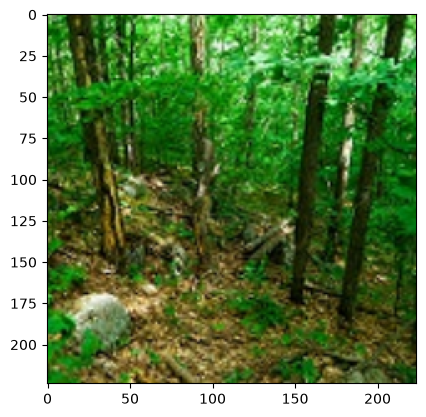

In [100]:
plt.imshow(img_test)

In [101]:

labels_counts=[]

for images,labels in train_ds:
    labels_counts.extend(labels)
    


    

In [102]:
labels_counts

[<tf.Tensor: shape=(6,), dtype=float32, numpy=array([1., 0., 0., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([1., 0., 0., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 0., 0., 0., 1.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([1., 0., 0., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 1., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 0., 1., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 0., 0., 0., 1.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 1., 0., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 0., 0., 0., 1.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([0., 0., 1., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=arra

In [103]:
# labels_df=pd.DataFrame({
#     "labels":map(int,labels_counts)
# })
    
# labels_df

In [104]:
# labels_df.value_counts()

- data is quiet balanced

# Layers Of Augmentation

In [112]:
data_aug=keras.models.Sequential([
    keras.layers.Rescaling(1/255),
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.05),
    keras.layers.RandomZoom(0.05),
    # keras.layers.RandomBrightness(0.2)
])

In [115]:
base_model=keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable=True

fine_tune_at=len(base_model.layers)-20

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable=False

# Main Model

In [116]:
model_intel=keras.models.Sequential([
    
    data_aug,
    
    base_model,
    # keras.layers.Conv2D(32,(3,3),activation="relu"),
    
    # keras.layers.Conv2D(64,(3,3),activation="relu"),
    keras.layers.GlobalAveragePooling2D(),
    # keras.layers.MaxPooling2D((2,2)),
    # keras.layers.Conv2D(128,(3,3),activation="relu"),
    # keras.layers.MaxPooling2D((2,2)),
    
    # keras.layers.Flatten(),
    keras.layers.Dense(256,activation="relu"),
    # keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(6,activation="softmax")]
    
    
)

In [117]:
from keras import metrics
from keras.callbacks import EarlyStopping

f1=metrics.F1Score(average="macro",name="f1_score")

early_stop=EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [118]:
model_intel.compile(
    optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy",f1]
)

# Training

In [119]:
history=model_intel.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20


c:\Users\Access\Desktop\intel_data\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 718s 2s/step - accuracy: 0.8677 - f1_score: 0.8693 - loss: 0.3896 - val_accuracy: 0.7627 - val_f1_score: 0.7382 - val_loss: 1.4961
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 591s 2s/step - accuracy: 0.9027 - f1_score: 0.9041 - loss: 0.2810 - val_accuracy: 0.8507 - val_f1_score: 0.8536 - val_loss: 0.6607
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 489s 1s/step - accuracy: 0.9147 - f1_score: 0.9158 - loss: 0.2359 - val_accuracy: 0.8735 - val_f1_score: 0.8725 - val_loss: 0.5447
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 663s 2s/step - accuracy: 0.9271 - f1_score: 0.9283 - loss: 0.1972 - val_accuracy: 0.8788 - val_f1_score: 0.8799 - val_loss: 0.4753
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 585s 2s/step - accuracy: 0.9375 - f1_score: 0.9384 - loss: 0.1829 - val_accuracy: 0.8339 - val_f1_score: 0.8325 - val_loss: 1.0437
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 565s 2s/step - accuracy: 0.9418 - f1_score: 0.9427 - loss: 0.1662 - val_accuracy: 0.7769 - val_f1_score: 0.7743 - va

In [120]:
model_intel.save("model_intel.keras")

# Test

In [3]:
model=keras.models.load_model("model_intel.keras")

In [ ]:
results=model.evaluate(test_ds)

94/94 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.8577 - f1_score: 0.8598 - loss: 0.5256


In [4]:
image_read=cv2.imread("intel/seg_pred/seg_pred/3.jpg")
img=cv2.resize(image_read,(224,224))

img=np.expand_dims(img,0)


prediction=model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [135]:
cv2.imshow("high",image_read)

In [130]:
prediction

array([[7.2441231e-05, 1.5420049e-10, 1.1113831e-09, 6.6057533e-12,
        8.9844972e-13, 9.9992752e-01]], dtype=float32)

In [131]:
np.argmax(prediction)

np.int64(5)

In [132]:
class_names[5]

'street'

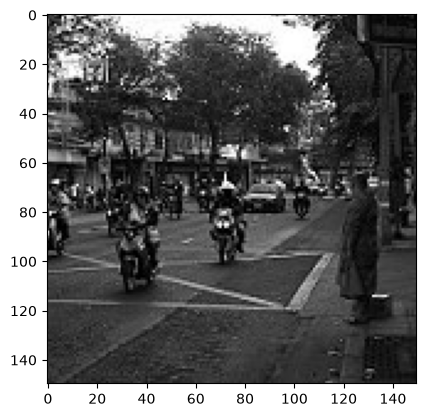

In [5]:
import matplotlib.pyplot as plt
plt.imshow(image_read)